## 1) 01_build_inputs

### 1.1) Build Inputs

This notebook builds the aligned hourly input table for the Phase 2 mini-grid case study.

The input table combines:

- actual irradiance
- forecast irradiance from Phase 1
- ambient temperature
- a synthetic peri-urban load profile

All series are aligned to a shared hourly datetime index.

### 1.2) Import

In [13]:
import pandas as pd 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from src.load_model import periurban_load_profile

### 1.3) Load Phase 1 Forecast Artifact

In [14]:
df = pd.read_csv("../data/raw/phase1_forecast_artifact.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)    # parses the date time correctly

df = df.sort_values("time").reset_index(drop=True)   # ensures consistent ordering

print(df.head())
print(df.columns.tolist())
print("Rows:", len(df))

                       time  ghi_actual_wh_m2  ghi_forecast_wh_m2  temp_c
0 2025-01-01 00:00:00+00:00               0.0          -37.120411   20.26
1 2025-01-01 01:00:00+00:00               0.0          -24.734124   19.19
2 2025-01-01 02:00:00+00:00               0.0           -1.256367   18.34
3 2025-01-01 03:00:00+00:00               0.0           31.248153   17.54
4 2025-01-01 04:00:00+00:00               0.0           70.391975   16.76
['time', 'ghi_actual_wh_m2', 'ghi_forecast_wh_m2', 'temp_c']
Rows: 8735


### 1.4) Basic Validatiom

In [15]:
required_cols = ["time", "ghi_actual_wh_m2", "ghi_forecast_wh_m2", "temp_c"]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("No missing required columns.")
print("Null counts:")
print(df[required_cols].isna().sum())

No missing required columns.
Null counts:
time                  0
ghi_actual_wh_m2      0
ghi_forecast_wh_m2    0
temp_c                0
dtype: int64


### 1.5) Build Load Profiles

In [16]:
# the code below adds the synthetic peri-urban demand profile directly into the aligned dataframe

times = pd.DatetimeIndex(df["time"])

load_kw = periurban_load_profile(
    times=times,
    base_kw=20.0,
    peak_kw=80.0,
    seed=42
)

df["load_kw"] = load_kw.values

df.head()

,time,ghi_actual_wh_m2,ghi_forecast_wh_m2,temp_c,load_kw
0,2025-01-01 00:00:00+00:00,0.0,-37.120411,20.26,20.182830
1,2025-01-01 01:00:00+00:00,0.0,-24.734124,19.19,19.426256
2,2025-01-01 02:00:00+00:00,0.0,-1.256367,18.34,20.758769
3,2025-01-01 03:00:00+00:00,0.0,31.248153,17.54,21.819825
4,2025-01-01 04:00:00+00:00,0.0,70.391975,16.76,22.388684


### 1.6) Save Input Table

In [17]:
output_dir = Path("../data/processed") 
output_dir.mkdir(parents=True, exist_ok=True)

inputs_path = output_dir / "phase2_inputs.csv"
df.to_csv(inputs_path, index=False)

print("Saved:", inputs_path)

Saved: ..\data\processed\phase2_inputs.csv


### 1.7) Quick Pot: actual vs forecast GHI (1–2 weeks)

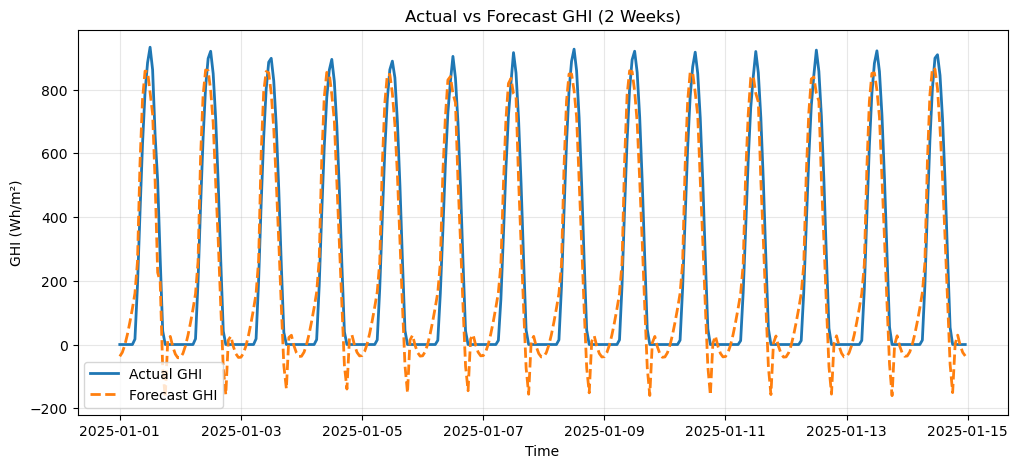

In [18]:
plot_start = "2025-01-01"
plot_end = "2025-01-15"

df_plot = df[(df["time"] >= plot_start) & (df["time"] < plot_end)].copy()

plt.figure(figsize=(12, 5))
plt.plot(df_plot["time"], df_plot["ghi_actual_wh_m2"], label="Actual GHI", linewidth=2)
plt.plot(df_plot["time"], df_plot["ghi_forecast_wh_m2"], label="Forecast GHI", linestyle="--", linewidth=2)
plt.xlabel("Time")
plt.ylabel("GHI (Wh/m²)")
plt.title("Actual vs Forecast GHI (2 Weeks)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 1.8) Quick Plot: load profile (1-2 weeks)

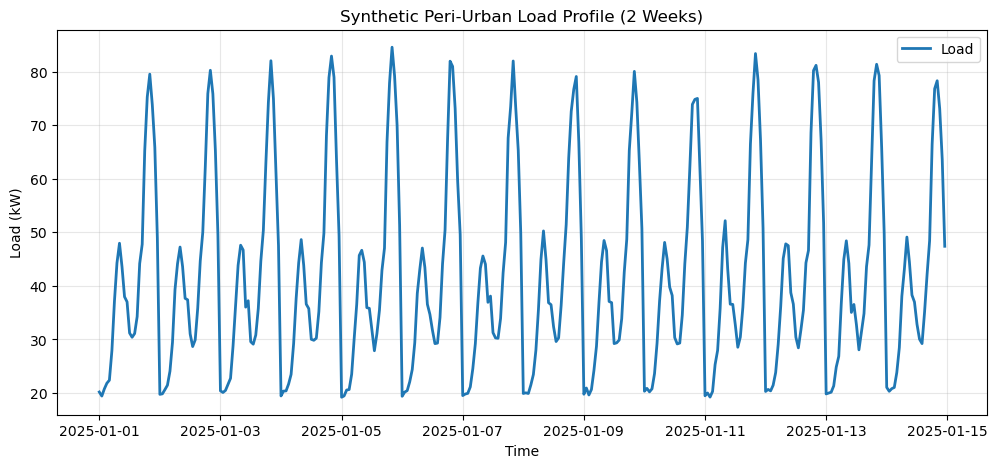

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df_plot["time"], df_plot["load_kw"], label="Load", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Load (kW)")
plt.title("Synthetic Peri-Urban Load Profile (2 Weeks)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 1.9) Input Check

The aligned input table now contains actual irradiance, forecast irradiance, temperature,
and synthetic peri-urban demand on a shared hourly timestamp index.

The load profile is synthetic but intentionally shaped to reflect:

- morning activity pickup
- moderate daytime demand
- strong evening peak

This provides a reproducible operational stress-test input for the mini-grid simulation.